# Notebook 01 — Tract-level choropleths (Figs. 2, 7, 8)

Reproduces three figures from *Trajectory-Integrated Public EVCS Accessibility (TI-acs)*:

- **Fig. 2** (`fig:access_map`, §3.1): 2024 Bay-area maps of TI-acs [hours] for L2 and DCFC + 2012–2024 median/IQR trend vs. installed ports.
- **Fig. 7** (`fig:TI-acs-hour-year`, Appendix): multi-year (every 3 yrs) Bay-area maps of TI-acs **[hours]**.
- **Fig. 8** (`fig:TI-acs-port-year`, Appendix): multi-year Bay-area maps of TI-acs **[ports]**.

All three figures are tract-level choropleths over the six Bay-Area counties (Alameda, Contra Costa, Marin, San Francisco, San Mateo, Santa Clara).


In [1]:
# Configuration (single source of truth) --------------------------------------
#
# Paper-reproducing parameters — DO NOT edit to replicate Figs. 2, 7, 8.
# Alternative values supported by the shipped data are noted below each line;
# anything else will raise a clear ValueError in ti_acs.io.

DIST            = 1000                       # m. Only 1000 m is stored in the annual files.
YEAR_FOCUS      = 2024                       # year for the headline Fig. 2 a/b maps
YEAR_RANGE      = list(range(2012, 2025))    # 2012-2024 (all years) for Fig. 2 c/d trend
YEARS_MULTIMAP  = list(range(2012, 2025, 3)) # 2012, 2015, 2018, 2021, 2024 — Fig. 7 & Fig. 8
MIN_TRACT_POP   = 500                        # exclude edge tracts with sparse population

# === Alternative configurations supported by the shipped data ===============
# DIST            ∈ {1000}                       (annual stats files contain DIST=1000 only)
# YEAR_FOCUS      ∈ {2012, 2013, ..., 2024}
# YEAR_RANGE      ⊆ 2012..2024
# YEARS_MULTIMAP  ⊆ 2012..2024


In [2]:
# Imports & path setup --------------------------------------------------------
import sys, os
# Make ti_acs importable from notebooks/ (one level deep). No external paths.
_repo = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _repo not in sys.path:
    sys.path.insert(0, _repo)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from ti_acs import io, plotting
from ti_acs.style import BAY_COUNTY_FIPS

# Output directory for saved figures.
FIG_DIR = os.path.join(_repo, "outputs", "figs")
os.makedirs(FIG_DIR, exist_ok=True)


## Load the tract-level TI-acs stats

Each tract is described by a row, and each column is named `"{year}_{level}_{dist}_{metric}"` where:

- `year` ∈ 2012..2024
- `level` ∈ {L2, DCFC}
- `dist` is the distance threshold in meters
- `metric` is the segment: `all` (full day), `home`, `HnW` (home + work), `SuperOffPeak`, `OffPeak`, `Peak`

We multiply by 24 because the file stores TI-acs as a *fraction of the day*; the paper reports hours-per-day.


In [3]:
# Load + light cleanup --------------------------------------------------------
# Validate the chosen (year, dist) combos against what each file actually contains.
io.validate_config("hours_annual", years=YEAR_RANGE, dists=[DIST])
io.validate_config("ports_annual", years=YEARS_MULTIMAP, dists=[DIST])

hours_dfs = io.load_tract_stats("hours_annual")   # for Fig. 2 + Fig. 7
ports_dfs = io.load_tract_stats("ports_annual")   # for Fig. 8

def clean_stats(stats_dfs, to_hours=True):
    # Filter sparse tracts and convert duration to hours-per-day.
    # The data file stores TI-acs [duration] as a fraction of the day (0..1);
    # multiplying by 24 yields hours-per-day, which is how the paper reports
    # it. The 'num_users' sheet is the tract population (left as-is).
    pop = stats_dfs["num_users"]["num_users"]
    keep_idx = pop[pop > MIN_TRACT_POP].index
    out = {}
    for k, df in stats_dfs.items():
        df2 = df.loc[keep_idx]
        if to_hours and k != "num_users":
            df2 = df2 * 24
        out[k] = df2
    return out

hours_dfs = clean_stats(hours_dfs, to_hours=True)
ports_dfs = clean_stats(ports_dfs, to_hours=False)   # ports = port count, no unit conversion
print(f"After population filter (>{MIN_TRACT_POP}): {len(hours_dfs['mean'])} tracts")


After population filter (>500): 1428 tracts


In [4]:
# Load geography & cumulative installed-port counts ---------------------------
shapes = io.load_shapefiles()
gdf_tract = shapes["tract"]
gdf_county = shapes["county"]

# Compute total installed L2 / DCFC ports per year for the Fig. 2 trend lines.
# "Open Date" gives the calendar date a station came online; any station with
# Open Date ≤ year-end-of-Y is treated as available in year Y. June-2024 cutoff
# follows the paper (§2.3).
evcs = io.load_evcs()
evcs_gdf = gpd.GeoDataFrame(evcs,
    geometry=gpd.points_from_xy(evcs["Longitude"], evcs["Latitude"]),
    crs="EPSG:4326",
).to_crs(gdf_tract.crs)
evcs_gdf = gpd.sjoin(evcs_gdf, gdf_tract[["geometry"]], how="inner", predicate="intersects")

# Build a (year × {L2, DCFC}) DataFrame of cumulative installed ports.
total_ports = {}
for year in YEAR_RANGE:
    open_mask = evcs_gdf["Open Date"] <= f"{year}-12-31"
    yr_df = (evcs_gdf[open_mask]
             .agg({"EV Level2 EVSE Num": "sum", "EV DC Fast Count": "sum"}))
    total_ports[year] = {"L2": yr_df["EV Level2 EVSE Num"],
                         "DCFC": yr_df["EV DC Fast Count"]}
total_ports = pd.DataFrame(total_ports).T   # rows = years
total_ports.head()


,L2,DCFC
2012,149.0,11.0
2013,211.0,43.0
2014,306.0,49.0
2015,386.0,79.0
2016,508.0,84.0


## Fig. 2 — 2024 TI-acs [hours] maps + 2012–2024 trend

Sub-panels:
- **a, b**: choropleth of average TI-acs [hours] in 2024 within `DIST` m, for L2 and DCFC.
- **c, d**: median (line) and IQR (shaded band) of tract-level TI-acs [hours] over 2012–2024, with the cumulative installed-port count on the right-hand axis (dashed).


In [5]:
# Build the per-year, per-level quantile table for the trend ------------------
# Trend lines use the *across-tract* mean / 25th-50th-75th of TI-acs [hours].
# We use the "mean" sheet (i.e. each tract's average over its residents) as the
# per-tract value, then take quantiles across tracts.
zone_stats = hours_dfs["mean"]

quantile_year = {}
for level in ("L2", "DCFC"):
    rows = {}
    for year in YEAR_RANGE:
        col = f"{year}_{level}_{DIST}_all"
        rows[year] = zone_stats[col].quantile([0.25, 0.50, 0.75])
    quantile_year[level] = pd.DataFrame(rows).T
quantile_year["L2"].tail()


,0.25,0.50,0.75
2020,1.962921,2.648019,6.823127
2021,2.550168,3.630306,8.978922
2022,2.773273,4.113091,9.998323
2023,3.171208,4.901756,12.009170
2024,3.291620,5.209062,12.536585


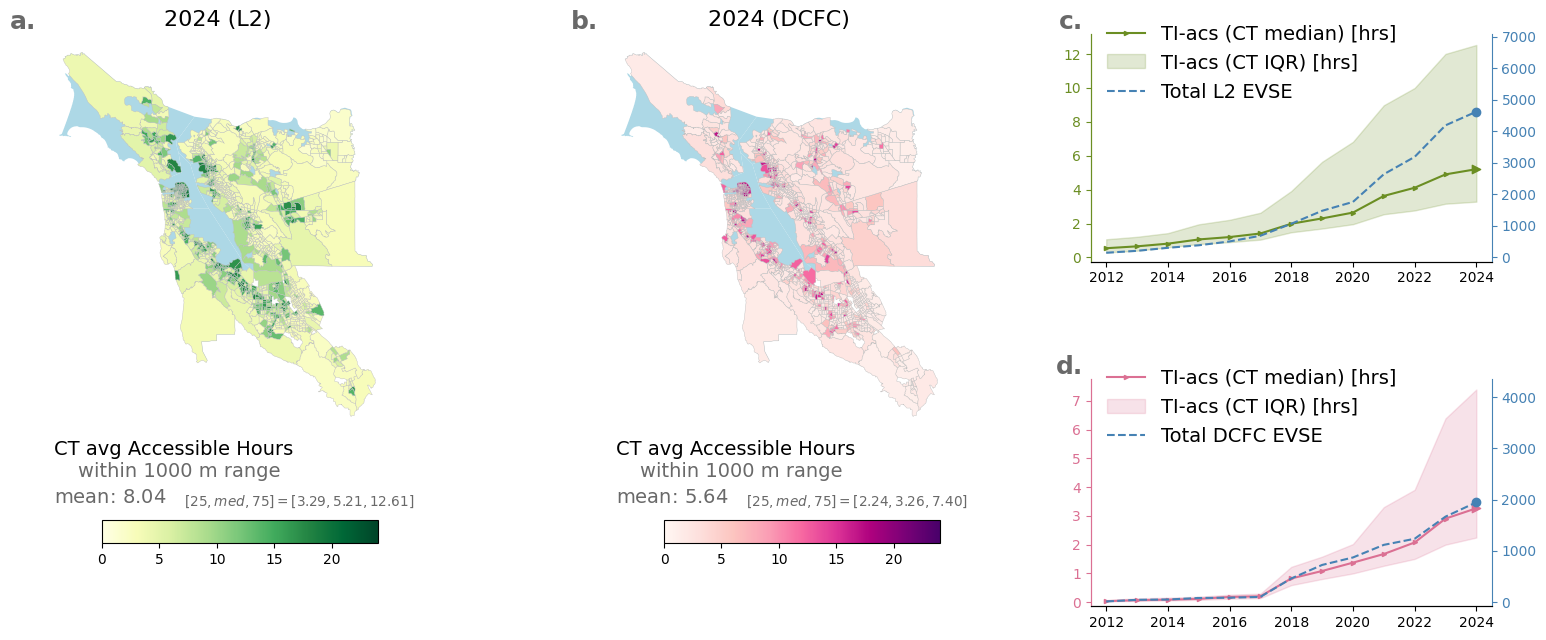

In [6]:
# Assemble Fig. 2 -------------------------------------------------------------
fig = plt.figure(figsize=(16, 6.5))
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[2, 2, 1.6])

ax_map_L2   = fig.add_subplot(gs[:, 0])
ax_map_DCFC = fig.add_subplot(gs[:, 1])
ax_trend_L2 = fig.add_subplot(gs[0, 2])
ax_trend_DC = fig.add_subplot(gs[1, 2])

# Maps (a, b): join the per-tract mean onto geometry, then call plot_tract_choropleth.
for ax, level in [(ax_map_L2, "L2"), (ax_map_DCFC, "DCFC")]:
    col = f"{YEAR_FOCUS}_{level}_{DIST}_all"
    gdf_join = gdf_tract.copy()
    gdf_join[col] = zone_stats[col].reindex(gdf_join.index)
    plotting.plot_tract_choropleth(
        ax, gdf_join, gdf_county, value_col=col,
        level=level, year=YEAR_FOCUS, dist=DIST, metric_kind="hours",
    )

# Trends (c, d)
for ax, level in [(ax_trend_L2, "L2"), (ax_trend_DC, "DCFC")]:
    plotting.plot_ti_acs_trend(ax, quantile_year[level], total_ports[level],
                                level=level, metric_kind="hours")

# Panel labels
for i, ax in enumerate([ax_map_L2, ax_map_DCFC, ax_trend_L2, ax_trend_DC]):
    ax.text(-0.02, 1, chr(97 + i) + ".", fontsize=18, ha="right", va="bottom",
            fontweight="bold", color="dimgrey", transform=ax.transAxes)

plt.tight_layout(w_pad=1, h_pad=5)
fig.savefig(os.path.join(FIG_DIR, "fig2_access_map.png"), dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## Fig. 7 — Multi-year TI-acs [hours] maps (Appendix)

Same choropleth recipe as Fig. 2 a/b, repeated over `YEARS_MULTIMAP`.


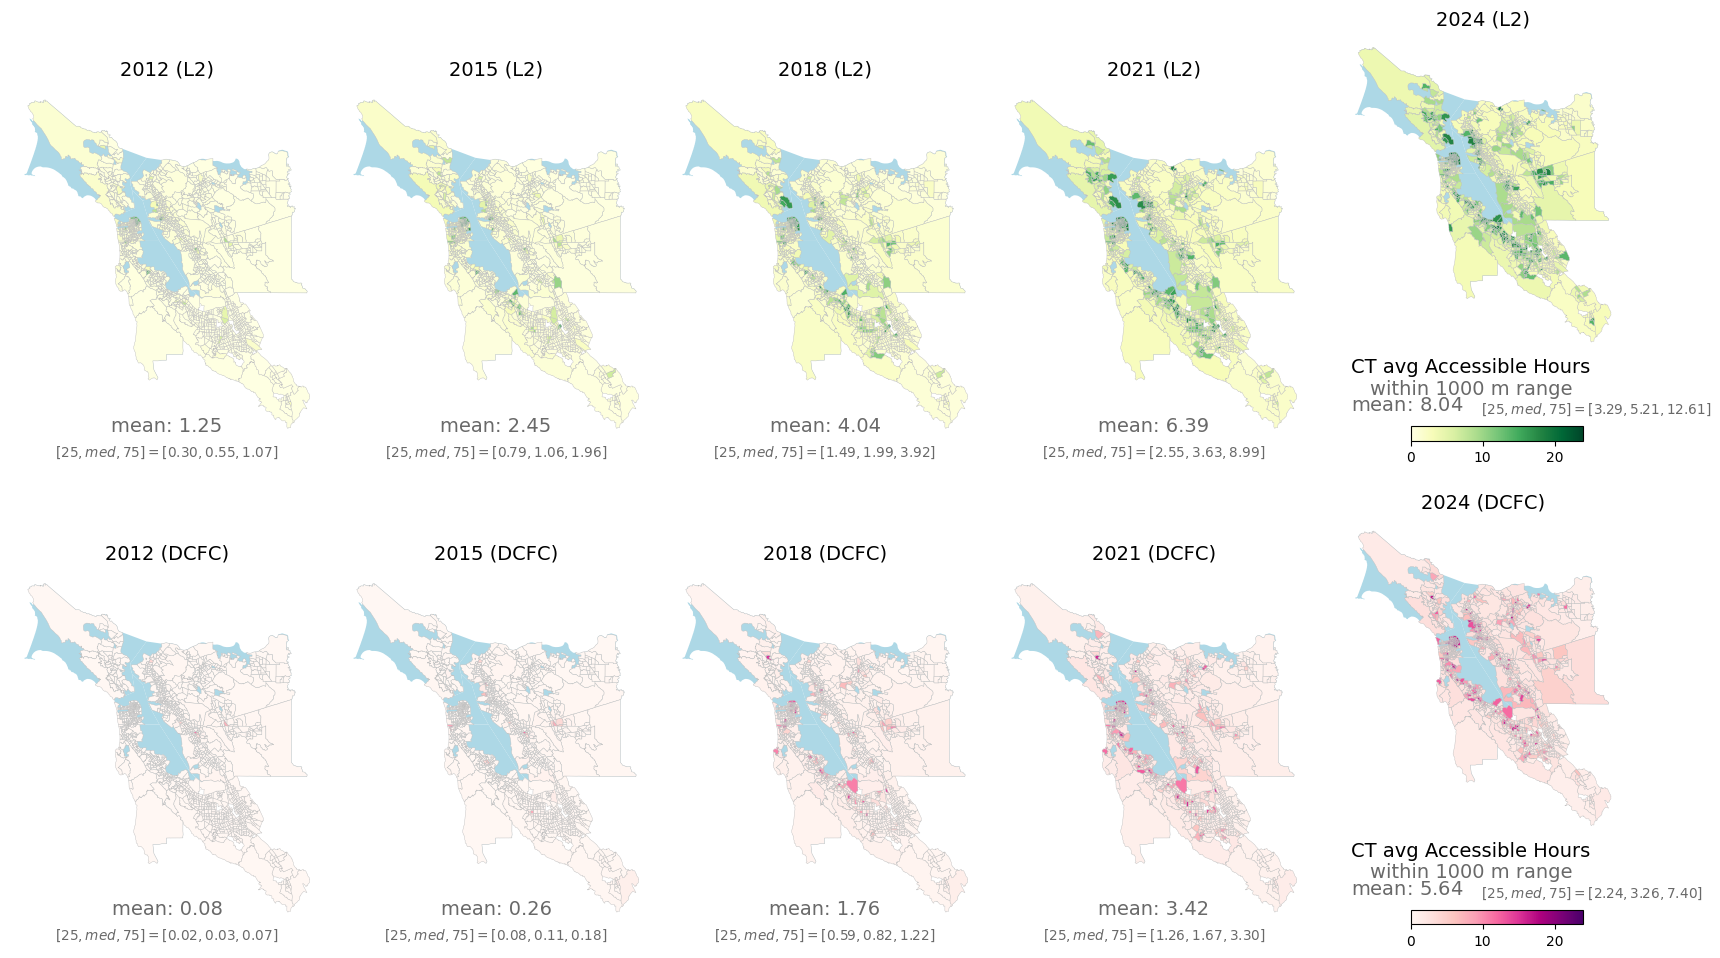

In [7]:
# Assemble Fig. 7 -------------------------------------------------------------
fig, axs = plt.subplots(2, len(YEARS_MULTIMAP), figsize=(18, 10))
for i, year in enumerate(YEARS_MULTIMAP):
    for j, level in enumerate(["L2", "DCFC"]):
        ax = axs[j, i]
        col = f"{year}_{level}_{DIST}_all"
        gdf_join = gdf_tract.copy()
        gdf_join[col] = zone_stats[col].reindex(gdf_join.index)
        plotting.plot_tract_choropleth(
            ax, gdf_join, gdf_county, value_col=col,
            level=level, year=year, dist=DIST, metric_kind="hours",
            # Colorbar only on the rightmost map of each row keeps the grid compact.
            legend=(i == len(YEARS_MULTIMAP) - 1), title_fontsize=14,
        )

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig7_TI-acs-hours-multiyear.png"),
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## Fig. 8 — Multi-year TI-acs [ports] maps (Appendix)

Same recipe, but using the *ports* metric. The colorbar caps at 15 ports for L2 and 10 for DCFC (heavy long-tail in the raw count distribution); values above cap extend.


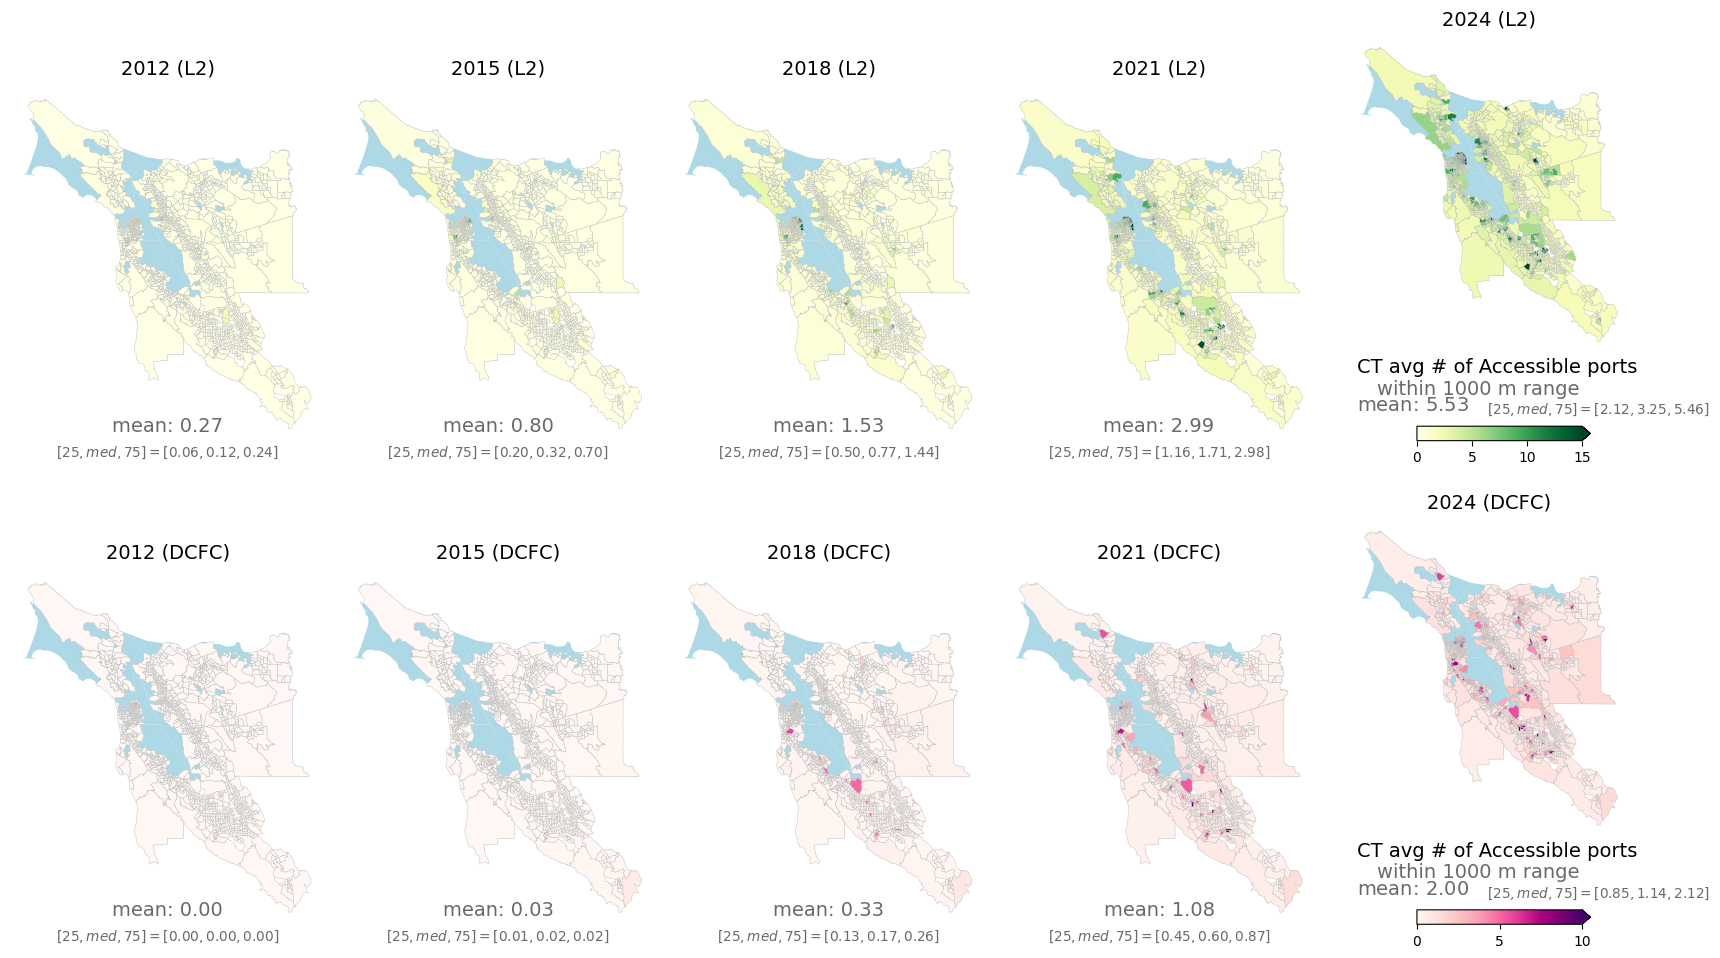

In [8]:
# Assemble Fig. 8 -------------------------------------------------------------
zone_stats_ports = ports_dfs["mean"]

fig, axs = plt.subplots(2, len(YEARS_MULTIMAP), figsize=(18, 10))
for i, year in enumerate(YEARS_MULTIMAP):
    for j, level in enumerate(["L2", "DCFC"]):
        ax = axs[j, i]
        col = f"{year}_{level}_{DIST}_all"
        gdf_join = gdf_tract.copy()
        gdf_join[col] = zone_stats_ports[col].reindex(gdf_join.index)
        plotting.plot_tract_choropleth(
            ax, gdf_join, gdf_county, value_col=col,
            level=level, year=year, dist=DIST, metric_kind="ports",
            legend=(i == len(YEARS_MULTIMAP) - 1), title_fontsize=14,
        )

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig8_TI-acs-ports-multiyear.png"),
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
